In [1]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
base_path = f'../../data/{NUTS2}/results/'

In [5]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_CMacedonia_Results_2010-2022.csv',
 'GR_CMacedonia_Results_2023-August-1st.csv',
 'GR_CMacedonia_Results_2023-August-1st_(new).csv',
 'GR_CMacedonia_Results_2023-July-1st.csv',
 'GR_CMacedonia_Results_2023-July-1st_(new).csv',
 'GR_CMacedonia_Results_2023-July-2nd.csv',
 'GR_CMacedonia_Results_2023-July-2nd_(new).csv',
 'GR_CMacedonia_Results_2023-June-1st.csv',
 'GR_CMacedonia_Results_2023-June-1st_(new).csv',
 'GR_CMacedonia_Results_2023-June-2nd.csv',
 'GR_CMacedonia_Results_2023-June-2nd_(new).csv',
 'GR_CMacedonia_Results_2023-May-1st.csv',
 'GR_CMacedonia_Results_2023-May-1st_(new).csv',
 'GR_CMacedonia_Results_2023-May-2nd.csv',
 'GR_CMacedonia_Results_2023-May-2nd_(new).csv']

In [6]:
del file_list[1:15:2]

In [7]:
file_list

['GR_CMacedonia_Results_2010-2022.csv',
 'GR_CMacedonia_Results_2023-August-1st_(new).csv',
 'GR_CMacedonia_Results_2023-July-1st_(new).csv',
 'GR_CMacedonia_Results_2023-July-2nd_(new).csv',
 'GR_CMacedonia_Results_2023-June-1st_(new).csv',
 'GR_CMacedonia_Results_2023-June-2nd_(new).csv',
 'GR_CMacedonia_Results_2023-May-1st_(new).csv',
 'GR_CMacedonia_Results_2023-May-2nd_(new).csv']

In [8]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [9]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

<AxesSubplot:>

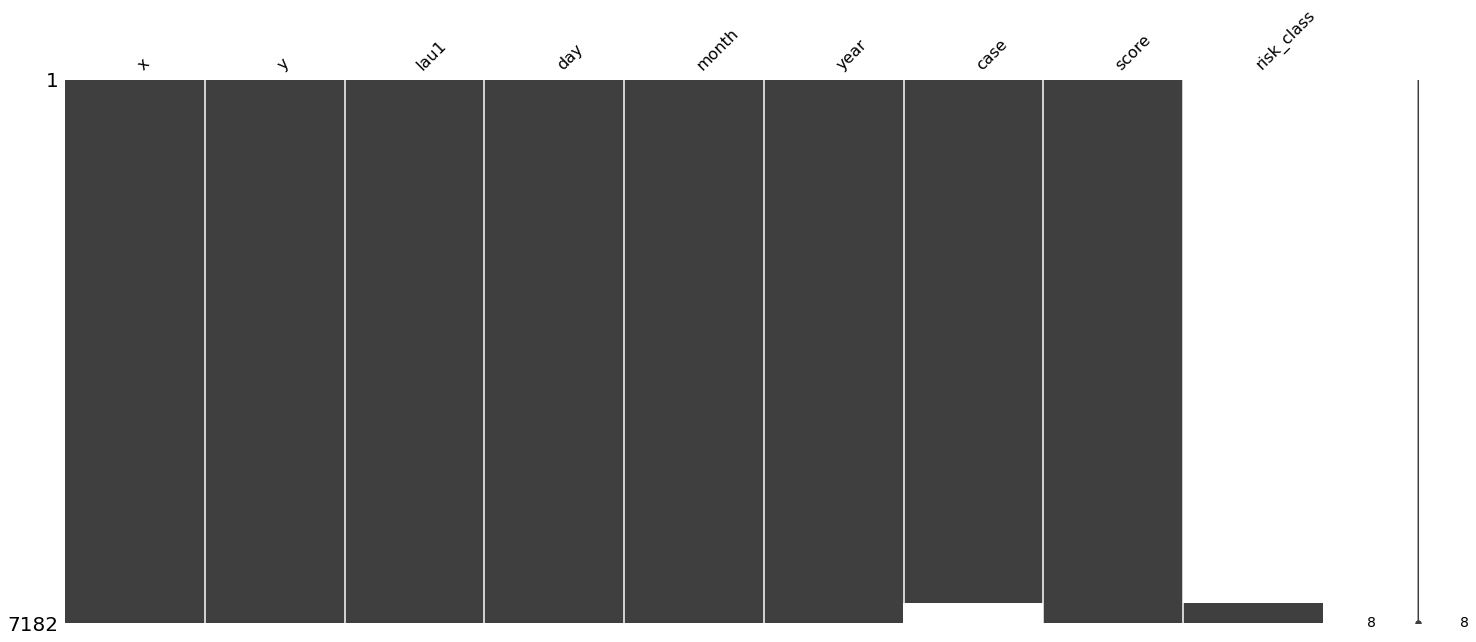

In [10]:
missingno.matrix(concated)

In [11]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [12]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [13]:
years = np.sort(concated.year.unique())
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int64)

In [14]:
df = concated[(concated['month'] >= 5) & (concated['month'] <= 8)].copy()

In [15]:
condition = df[(df['month'] == 8) & (df['day'] == 16)].index
df.drop(condition, inplace = True)
df

,x,y,lau1,day,month,year,case,score,risk_class
4,22.46197,40.60446,αλεξανδρειας,1,8,2021,1.0,0.988241,NaN
5,22.36451,40.79600,πελλας,1,8,2013,0.0,0.987991,NaN
9,22.72632,40.61725,δελτα,1,8,2021,1.0,0.985321,NaN
12,22.36451,40.79600,πελλας,1,8,2018,1.0,0.984573,NaN
13,22.72632,40.61725,δελτα,1,8,2018,1.0,0.984428,NaN
...,...,...,...,...,...,...,...,...,...
7177,23.85648,41.01727,νεας ζιχνης,16,5,2023,NaN,0.515425,2.0
7178,22.07722,41.01522,αλμωπιας,16,5,2023,NaN,0.490651,2.0
7179,22.97547,40.65206,νεαπολης συκεων,16,5,2023,NaN,0.474692,2.0
7180,22.47539,40.12020,διου ολυμπου,16,5,2023,NaN,0.420317,2.0


In [16]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_2023.csv'

bins = []

with open(bins_path, mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        bins.extend(map(float, row))

print(bins)

[0.0, 0.0648252687608289, 0.3787123377107355, 0.6803072708219687, 0.838221147727126, 0.935474790938512, 1.0]


In [17]:
df['risk_class'] = pd.cut(df['score'], bins=bins, labels=False, include_lowest=True)
df.head(10)

,x,y,lau1,day,month,year,case,score,risk_class
4,22.46197,40.60446,αλεξανδρειας,1,8,2021,1.0,0.988241,5
5,22.36451,40.79600,πελλας,1,8,2013,0.0,0.987991,5
9,22.72632,40.61725,δελτα,1,8,2021,1.0,0.985321,5
12,22.36451,40.79600,πελλας,1,8,2018,1.0,0.984573,5
13,22.72632,40.61725,δελτα,1,8,2018,1.0,0.984428,5
21,22.37828,40.28551,κατερινης,1,8,2018,0.0,0.981149,5
22,22.36451,40.79600,πελλας,1,8,2021,1.0,0.980961,5
26,22.46197,40.60446,αλεξανδρειας,1,8,2018,1.0,0.980245,5
29,22.46197,40.60446,αλεξανδρειας,1,8,2013,0.0,0.979028,5
30,22.95369,40.62334,θεσσαλονικης,1,8,2014,0.0,0.978884,5


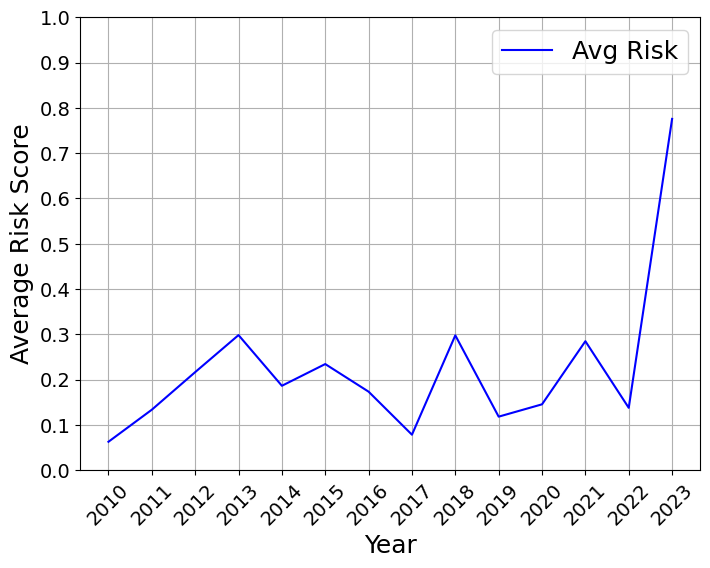

In [18]:
plot_trend_curve(df, plot_max = False, score_col = 'score', plot_cases=False, y_label='Average Risk Score')

In [19]:
risk_2022_over_7 = df[(df['year'] == 2022) & (df['risk_class'] >= 4)].copy()
risk_2022_over_7.reset_index(drop = True, inplace = True)
risk_2022_over_7

,x,y,lau1,day,month,year,case,score,risk_class
0,22.95369,40.62334,θεσσαλονικης,1,8,2022,0.0,0.943055,5
1,22.36451,40.79600,πελλας,1,8,2022,1.0,0.870200,4
2,22.72632,40.61725,δελτα,1,8,2022,0.0,0.861390,4
3,22.17237,40.79674,σκυδρας,1,8,2022,0.0,0.856029,4
4,22.46197,40.60446,αλεξανδρειας,1,8,2022,1.0,0.852084,4


In [20]:
risk_2023_over_7 = df[(df['year'] == 2023) & (df['risk_class'] >= 4)].copy()
risk_2023_over_7.reset_index(drop = True, inplace = True)
risk_2023_over_7

,x,y,lau1,day,month,year,case,score,risk_class
0,22.90326,40.67609,κορδελιου ευοσμου,1,8,2023,NaN,0.992797,5
1,22.91743,40.42897,θερμαϊκου,1,8,2023,NaN,0.990260,5
2,22.72632,40.61725,δελτα,1,8,2023,NaN,0.989307,5
3,22.95369,40.62334,θεσσαλονικης,1,8,2023,NaN,0.982542,5
4,22.89198,40.65603,αμπελοκηπων μενεμενης,1,8,2023,NaN,0.978483,5
...,...,...,...,...,...,...,...,...,...
134,23.49303,40.69079,βολβης,16,5,2023,NaN,0.884950,4
135,22.89198,40.65603,αμπελοκηπων μενεμενης,16,5,2023,NaN,0.883310,4
136,22.90881,40.77096,ωραιοκαστρου,16,5,2023,NaN,0.862982,4
137,23.57073,40.89405,βισαλτιας,16,5,2023,NaN,0.857905,4
